1.  What is Boosting in Machine Learning? Explain how it improves weak learners.

- **Boosting** is an ensemble learning method that sequentially combines multiple weak learners (models that perform slightly better than random guessing) to create a single strong learner. The core idea is to train weak learners iteratively, with each new learner focusing on correcting the errors made by the previous ones.

- How it Improves Weak Learners:

  - **Sequential Learning:** Unlike bagging (e.g., Random Forest), where learners are trained independently, boosting trains them in sequence. Each subsequent weak learner is built to pay more attention to the data instances that previous learners misclassified or handled poorly.

  - **Weighted Data/Errors:** In each iteration, the algorithm assigns higher weights to the misclassified data points (or errors). This forces the next weak learner to concentrate on these difficult examples, thereby reducing the overall error rate.

  -  **Combination:** The final strong learner is typically a weighted sum of all the weak learners. Learners that perform better on the overall dataset (or on the harder examples) might contribute more to the final prediction.

- **Analogy:** Imagine a team of students working on a tough problem. Instead of each student working alone, they work together. The first student tries to solve it, and then the next student focuses on the parts the first one got wrong, and so on. By combining their efforts, they collectively arrive at a much better solution than any single student could on their own.

2. What is the difference between AdaBoost and Gradient Boosting in terms of how models are trained?

- **AdaBoost (Adaptive Boosting):**
  - **Focus:** Primarily focuses on adjusting the weights of misclassified data points. In each iteration, it increases the weights of misclassified samples and decreases the weights of correctly classified samples.
  - **Model Contribution:** Each weak learner (often decision stumps or shallow trees) is assigned a weight based on its accuracy, and the final prediction is a weighted majority vote (for classification) or sum (for regression).
  - **Sequential Correction:** Subsequent models are trained on the re-weighted dataset, forcing them to pay more attention to previously misclassified instances.

- **Gradient Boosting:**
  - **Focus:** Focuses on reducing errors (residuals) by training subsequent models on the **residuals** (the differences between the actual and predicted values) of the previous models.
  - **Model Contribution:** Each weak learner (typically decision trees, but deeper than stumps) tries to predict the errors made by the ensemble so far, not the target variable itself. The final prediction is a sum of the predictions from all individual learners.
  - **Sequential Correction:** New models are trained to fit the negative gradient of the loss function with respect to the current ensemble's prediction, effectively moving towards minimizing the loss function.

- **Key Difference:** AdaBoost adjusts data point weights, while Gradient Boosting adjusts the errors/residuals that subsequent models try to predict.

3. How does regularization help in XGBoost?

- **Regularization in XGBoost:**
  - **Purpose:** Regularization techniques are crucial in XGBoost (and machine learning in general) to prevent overfitting. Overfitting occurs when a model learns the training data too well, capturing noise and specific patterns that don't generalize to new, unseen data.
  - **Bias-Variance Trade-off:** Regularization helps manage the bias-variance trade-off. By adding a penalty for model complexity, it encourages simpler models, which typically have higher bias but lower variance, leading to better generalization.
  - **Specific Regularization Techniques in XGBoost:**
    - **L1 Regularization (Lasso) and L2 Regularization (Ridge):** XGBoost incorporates both L1 ($\alpha$) and L2 ($\lambda$) regularization terms in its objective function. These penalties are applied to the weights (or leaf scores) of the trees. L1 regularization can lead to sparse solutions (some weights becoming zero), effectively performing feature selection, while L2 regularization encourages smaller, more distributed weights.
    - **Shrinkage (Learning Rate / `eta`):** This technique scales down the contribution of each new tree by a factor `eta` after it's been trained. This forces the learning process to be slower and requires more trees, which helps prevent individual trees from dominating the ensemble and reduces the risk of overfitting.
    - **Column Subsampling (`colsample_bytree`, `colsample_bylevel`, `colsample_bynode`):** Similar to Random Forests, XGBoost allows for subsampling of features (columns) when building each tree. This introduces randomness and prevents any single feature from having too much influence, thus reducing variance.
    - **Row Subsampling (`subsample`):** XGBoost also supports subsampling of training instances (rows) for each tree. This is another way to introduce randomness and reduce overfitting by training each tree on a different subset of the data.

- **Benefit:** By employing these regularization techniques, XGBoost can build powerful and complex models that are less prone to overfitting, resulting in better predictive performance on unseen data.

4. Why is CatBoost considered efficient for handling categorical data?

- **CatBoost's Efficiency with Categorical Data:**
  - **Ordered Boosting:** CatBoost introduces an 'ordered boosting' scheme, which is a permutation-driven approach to constructing gradients and leaf values. This helps overcome prediction shift (a type of overfitting) that can occur when processing categorical features.
  - **Oblivious Trees:** CatBoost uses oblivious decision trees, where the same splitting criterion is used for all nodes at the same level of the tree. This structure helps reduce overfitting and leads to faster prediction times.
  - **Feature Combinations:** CatBoost automatically generates and combines categorical features. For example, if you have 'Country' and 'City' as categorical features, CatBoost can create a new feature like 'Country_City' to capture interactions, which can be very powerful.
  - **Target Encoding without Leakage (Ordered Target Statistics):** CatBoost uses a unique method called 'Ordered Target Statistics' for converting categorical features into numerical ones. This method prevents target leakage (where information from the target variable 'leaks' into the feature calculation during training), which is a common problem with traditional target encoding techniques. It does this by calculating the target statistics based only on the history of the data seen before the current sample.
  - **Handling Missing Values:** CatBoost also has robust built-in mechanisms for handling missing values in categorical features, further simplifying preprocessing.

5. What are some real-world applications where boosting techniques are preferred over bagging methods?

- **Real-World Applications where Boosting is Preferred:**
  - **Fraud Detection:** Boosting algorithms are highly effective in identifying rare events like fraudulent transactions, where the dataset is often imbalanced, and correctly classifying the minority class is crucial.
  - **Recommendation Systems:** For tasks like predicting user preferences or item recommendations, boosting can capture complex non-linear relationships in data more effectively than some bagging methods.
  - **Medical Diagnosis:** In scenarios where high accuracy is paramount and misclassifications can have severe consequences (e.g., diagnosing diseases), boosting's ability to minimize errors iteratively is very valuable.
  - **Search Engine Ranking:** Boosting algorithms are widely used in search engines to rank web pages, where factors like relevance, authority, and freshness need to be combined to provide the most accurate search results.
  - **Ad Click-Through Rate (CTR) Prediction:** Predicting whether a user will click on an advertisement is a common application where boosting models excel due to their ability to handle large datasets and complex interactions between features.
  - **Anomaly Detection:** Similar to fraud detection, identifying unusual patterns or outliers in various domains (e.g., network intrusion detection, industrial fault detection) benefits from boosting's focus on hard-to-classify instances.
  - **Speech Recognition:** Boosting has been used in various stages of speech recognition systems, particularly in feature selection and classification tasks.

- **Reasons for Preference:**
  - **Higher Accuracy:** Boosting often achieves higher accuracy, especially on complex datasets, because it explicitly tries to reduce bias and error by focusing on previously misclassified samples.
  - **Handles Imbalanced Data Well:** Its iterative nature allows it to give more attention to minority classes, which is beneficial in datasets with class imbalance.
  - **Stronger Models from Weak Learners:** The sequential nature allows for building a very strong model from a series of simple, weak models, making it very flexible.

However, it's important to note that bagging methods (like Random Forests) are often preferred when dealing with very noisy data or when parallelism is a key concern, as individual models can be trained independently.

In [2]:
'''6. Use sklearn.datasets.load_breast_cancer() for classification tasks.
 Write a Python program to:
● Train an AdaBoost Classifier on the Breast Cancer dataset
● Print the model accuracy'''

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score

# Load the Breast Cancer dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Initialize the AdaBoost Classifier
# We'll use a DecisionTreeClassifier as the base estimator, which is common for AdaBoost
adaboost_model = AdaBoostClassifier(random_state=42)

# Train the AdaBoost Classifier
adaboost_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = adaboost_model.predict(X_test)

# Calculate and print the model accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"AdaBoost Classifier Accuracy: {accuracy:.4f}")

AdaBoost Classifier Accuracy: 0.9708


In [3]:
'''7. Use sklearn.datasets.fetch_california_housing() for regression
tasks.
  Write a Python program to:
● Train a Gradient Boosting Regressor on the California Housing dataset
● Evaluate performance using R-squared score'''


from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score

# Load the California Housing dataset
housing = fetch_california_housing()
X = housing.data
y = housing.target

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Initialize the Gradient Boosting Regressor
gbr_model = GradientBoostingRegressor(random_state=42)

# Train the model
gbr_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_gbr = gbr_model.predict(X_test)

# Calculate and print the R-squared score
r2 = r2_score(y_test, y_pred_gbr)
print(f"Gradient Boosting Regressor R-squared score: {r2:.4f}")

Gradient Boosting Regressor R-squared score: 0.7803


In [7]:
'''8.  Write a Python program to:
● Train an XGBoost Classifier on the Breast Cancer dataset
● Tune the learning rate using GridSearchCV
● Print the best parameters and accuracy'''

import xgboost as xgb
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

# Load the Breast Cancer dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Initialize the XGBoost Classifier
# Use 'objective="binary:logistic"' for binary classification and 'eval_metric="logloss"'
xgb_model = xgb.XGBClassifier(objective='binary:logistic', eval_metric='logloss', random_state=42)

# Define the parameter grid for learning_rate tuning
param_grid = {
    'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3]
}

# Initialize GridSearchCV
# cv=3 for 3-fold cross-validation
# scoring='accuracy' to optimize for accuracy
grid_search = GridSearchCV(estimator=xgb_model, param_grid=param_grid, cv=3, scoring='accuracy', n_jobs=-1, verbose=1)

# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

# Print the best parameters found
print(f"Best parameters: {grid_search.best_params_}")

# Get the best model
best_xgb_model = grid_search.best_estimator_

# Make predictions on the test set with the best model
y_pred_xgb = best_xgb_model.predict(X_test)

# Calculate and print the accuracy of the best model
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
print(f"Best XGBoost Classifier Accuracy: {accuracy_xgb:.4f}")

Fitting 3 folds for each of 5 candidates, totalling 15 fits
Best parameters: {'learning_rate': 0.3}
Best XGBoost Classifier Accuracy: 0.9649


In [9]:
'''9. Write a Python program to:
● Train a CatBoost Classifier
● Plot the confusion matrix using seaborn'''

!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.8 MB/s eta 0:00:00


Training CatBoost Classifier...
Training complete.
CatBoost Classifier Accuracy: 0.9766


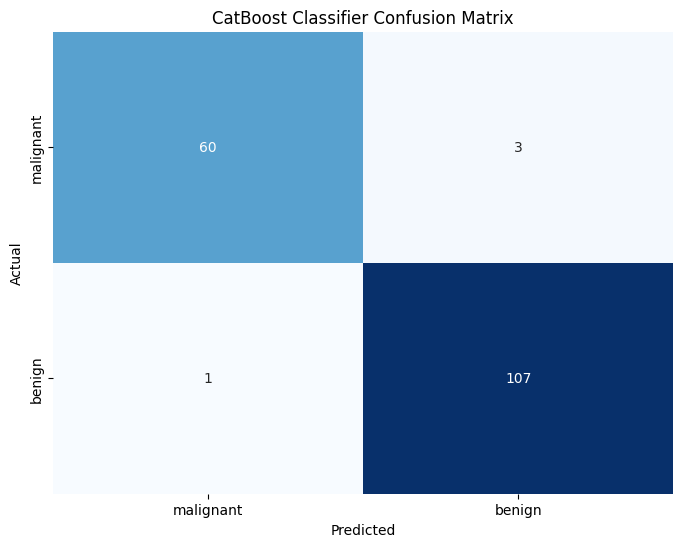

In [10]:
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.datasets import load_breast_cancer
import seaborn as sns
import matplotlib.pyplot as plt

# Load the Breast Cancer dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Initialize the CatBoost Classifier
# Set verbose=0 to suppress training output
cat_model = CatBoostClassifier(iterations=100,  # Number of boosting iterations
                               learning_rate=0.1, # Step size shrinkage
                               depth=6,         # Depth of the tree
                               loss_function='Logloss', # For binary classification
                               eval_metric='Accuracy', # Metric to monitor
                               random_seed=42,
                               verbose=0, # Suppress training output
                               early_stopping_rounds=10 # Stop if no improvement for 10 rounds
                              )

# Train the CatBoost Classifier
print("Training CatBoost Classifier...")
cat_model.fit(X_train, y_train, eval_set=(X_test, y_test))
print("Training complete.")

# Make predictions on the test set
y_pred_cat = cat_model.predict(X_test)

# Calculate and print the model accuracy
accuracy_cat = accuracy_score(y_test, y_pred_cat)
print(f"CatBoost Classifier Accuracy: {accuracy_cat:.4f}")

# Plot the confusion matrix
cm = confusion_matrix(y_test, y_pred_cat)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=data.target_names, yticklabels=data.target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('CatBoost Classifier Confusion Matrix')
plt.show()

10. You're working for a FinTech company trying to predict loan default using
customer demographics and transaction behavior.
The dataset is imbalanced, contains missing values, and has both numeric and
categorical features.
Describe your step-by-step data science pipeline using boosting techniques:
● Data preprocessing & handling missing/categorical values
● Choice between AdaBoost, XGBoost, or CatBoost
● Hyperparameter tuning strategy
● Evaluation metrics you'd choose and why
● How the business would benefit from your model

- Predicting loan defaults in a FinTech setting with imbalanced, messy data requires a robust pipeline that prioritizes high recall for the minority class (defaulters) while maintaining precision to maximize profitability.
- Here is the step-by-step data science pipeline utilizing boosting techniques.

**1. Data Preprocessing & Handling Missing/Categorical Values**
Given the mix of demographic and transaction data, the preprocessing stage is crucial for performance.
  - **Missing Values:** For numeric features, I will use Median Imputation (more robust to outliers than mean). For categorical features, I will create a new category labeled "Unknown" or use Mode Imputation, depending on whether the missingness is informative.
  - **Categorical Features:** I will use One-Hot Encoding for low-cardinality nominal features and Target Encoding for high-cardinality features (e.g., ZIP code), ensuring we do not introduce target leakage by using cross-validation within the encoding process.
  - **Outlier Handling:** Winsorization or capping will be used on extreme transaction amounts to prevent model skew.
  - **Imbalance Management:** Since defaults are a minority class, I will use Class Weighting inside the boosting model (e.g., scale_pos_weight in XGBoost) to assign higher penalties for misclassifying defaults. Optionally, I would use SMOTE (Synthetic Minority Over-sampling Technique) on the training set.

**2. Choice of Boosting Technique: CatBoost**
- I would choose CatBoost over AdaBoost or XGBoost for this specific problem.
   - **Why CatBoost:** It excels at handling categorical features automatically without requiring preprocessing like One-Hot Encoding, which avoids increasing the feature space drastically. It also mitigates target leakage through its unique "ordered boosting" technique and offers superior out-of-the-box performance on imbalanced datasets.
  - **Alternative:** XGBoost is a strong second choice, especially if the dataset is mostly numerical and training speed is the top priority.

**3. Hyperparameter Tuning Strategy**
- To optimize CatBoost, I will use Bayesian Optimization (e.g., Optuna) rather than grid search, as it is more efficient in finding optimal parameters within a shorter time.
- Parameters to Tune:
  - **iterations:** Number of trees.
learning_rate: Low learning rate with higher iterations.
  - **depth:** Typically 4-10 (deeper can cause overfitting).
  - **l2_leaf_reg:** Regularization to prevent overfitting.
  - **border_count:** For numerical feature quantization.
- **Validation:** I will use Stratified 5-Fold Cross-Validation to ensure the ratio of defaults is preserved in each fold, preventing bias.

4. **Evaluation Metrics**
- In a lending scenario, failing to identify a defaulter (False Negative) is much costlier than misclassifying a good borrower (False Positive).
  - **Primary Metric: Recall (Sensitivity):** I need to maximize the percentage of actual defaults that are correctly identified.
  - **Secondary Metric: Area Under the Precision-Recall Curve (AUC-PRC):** Better than ROC-AUC for highly imbalanced data because it focuses on the performance regarding the minority class.
  - **Final Metric: F1-Score/F2-Score:** To find the optimal balance between precision and recall, with F2 prioritizing recall more heavily.

**5. Business Benefits**
- Implementing this pipeline provides the following benefits:
  - **Reduced Default Rates & Loss Reduction:** By accurately identifying high-risk borrowers, the company reduces the cost of non-performing loans.
  - **Reduction:** By accurately identifying high-risk borrowers, the company reduces the cost of non-performing loans.
  - **Increased Profitability:** High precision means fewer good customers are wrongly rejected, optimizing the approval rate.
  - **Improved Risk Assessment:** The model provides insights into the key drivers of default (e.g., specific transaction behaviors), helping in policy refinement.
  - **Automated Decision-Making:** Real-time scoring enables fast loan approval workflows.